## CNN vs RL for Face Feature Extrction and Classification

In [9]:
import kagglehub
import os
import shutil
import random

# Step 1: Download dataset (only once)
if not os.path.exists("celeba_dataset"):
    path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
    shutil.move(path, "celeba_dataset")
else:
    print("Dataset already exists in project folder.")

dataset_path = os.path.abspath("celeba_dataset")
print("Dataset Path: ", dataset_path)

Dataset already exists in project folder.
Dataset Path:  d:\College Practical\ANNDL Practicals\TA CIA\celeba_dataset


In [37]:
import os
import shutil
import pandas as pd

# ---------- PATH FIX (VERY IMPORTANT) ----------
dataset_path = "celeba_dataset"

# CelebA has nested folder → fix this
img_dir = os.path.join(dataset_path, "img_align_celeba", "img_align_celeba")

# CSV file
attr_file = os.path.join(dataset_path, "list_attr_celeba.csv")

# ---------- VERIFY PATH ----------
print("Checking image directory...")
print("Exists:", os.path.exists(img_dir))
print("Sample images:", os.listdir(img_dir)[:5])

# ---------- LOAD DATA ----------
df = pd.read_csv(attr_file)

# Fix column name if needed
if "Smiling" not in df.columns:
    df.columns = df.columns.str.strip()
    print("Columns:", df.columns)

# ---------- CLEAN OLD DATASET ----------
if os.path.exists("dataset"):
    shutil.rmtree("dataset")

# ---------- CREATE FOLDERS ----------
base_dir = "dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

classes = ["smiling", "not_smiling"]

for split in [train_dir, val_dir]:
    for cls in classes:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

# ---------- PREPARE DATA ----------
data = df[["image_id", "Smiling"]].sample(20000, random_state=42)

data["Smiling"] = data["Smiling"].apply(
    lambda x: "smiling" if x == 1 else "not_smiling"
)

train_data = data.sample(frac=0.8, random_state=42)
val_data = data.drop(train_data.index)

# ---------- COPY FUNCTION (WITH DEBUG) ----------
def copy_images(dataframe, target_dir):
    copied = 0
    missing = 0

    for i, row in dataframe.iterrows():
        src = os.path.join(img_dir, row["image_id"])
        dst = os.path.join(target_dir, row["Smiling"], row["image_id"])

        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied += 1
        else:
            missing += 1

        if i % 1000 == 0:
            print(f"[{i}] Copied: {copied}, Missing: {missing}")

    print(f"FINAL → Copied: {copied}, Missing: {missing}")

# ---------- RUN ----------
print("\nCopying training images...")
copy_images(train_data, train_dir)

print("\nCopying validation images...")
copy_images(val_data, val_dir)

# ---------- FINAL CHECK ----------
def count_images(folder):
    total = 0
    for root, dirs, files in os.walk(folder):
        total += len(files)
    return total

print("\nFINAL DATASET CHECK:")
print("Train images:", count_images(train_dir))
print("Val images:", count_images(val_dir))

Checking image directory...
Exists: True
Sample images: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']

Copying training images...
[186000] Copied: 281, Missing: 0
[100000] Copied: 916, Missing: 0
[101000] Copied: 1659, Missing: 0
[137000] Copied: 4263, Missing: 0
[188000] Copied: 4360, Missing: 0
[99000] Copied: 4559, Missing: 0
[71000] Copied: 4743, Missing: 0
[120000] Copied: 6427, Missing: 0
[103000] Copied: 8545, Missing: 0
[95000] Copied: 8645, Missing: 0
[77000] Copied: 11355, Missing: 0
[25000] Copied: 12572, Missing: 0
[115000] Copied: 13013, Missing: 0
[15000] Copied: 14051, Missing: 0
[74000] Copied: 14556, Missing: 0
FINAL → Copied: 16000, Missing: 0

Copying validation images...
[64000] Copied: 274, Missing: 0
[133000] Copied: 346, Missing: 0
[17000] Copied: 389, Missing: 0
[60000] Copied: 630, Missing: 0
[48000] Copied: 991, Missing: 0
[75000] Copied: 2521, Missing: 0
[10000] Copied: 3382, Missing: 0
FINAL → Copied: 4000, Missing: 0

FINAL DATASET 

In [38]:
import os

def count_images(folder):
    total = 0
    for root, dirs, files in os.walk(folder):
        total += len(files)
    return root, total

print("Train images:", count_images("dataset/train"))
print("Val images:", count_images("dataset/val"))

Train images: ('dataset/train\\smiling', 16000)
Val images: ('dataset/val\\smiling', 4000)


In [39]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image parameters
IMG_SIZE = 128
BATCH_SIZE = 32

# Dataset path (CHANGE THIS)
train_dir = "dataset/train"
val_dir = "dataset/val"

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

num_classes = train_data.num_classes

# CNN Model
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Epoch 1/10
500/500 [==============================] - 34s 48ms/step - loss: 0.4468 - accuracy: 0.7682 - val_loss: 0.2608 - val_accuracy: 0.8888
Epoch 2/10
500/500 [==============================] - 26s 53ms/step - loss: 0.2432 - accuracy: 0.8993 - val_loss: 0.2305 - val_accuracy: 0.9030
Epoch 3/10
500/500 [==============================] - 19s 38ms/step - loss: 0.2153 - accuracy: 0.9131 - val_loss: 0.2225 - val_accuracy: 0.9040
Epoch 4/10
500/500 [==============================] - 18s 35ms/step - loss: 0.1988 - accuracy: 0.9172 - val_loss: 0.2268 - val_accuracy: 0.9015
Epoch 5/10
500/500 [==============================] - 19s 38ms/step - loss: 0.1885 - accuracy: 0.9208 - val_loss: 0.2322 - val_accuracy: 0.9047
Epoch 6/10
500/500 [==============================] - 19s 37ms/step - loss: 0.1706 - accuracy: 0.9301 - val_loss: 0.2383 - val_accuracy: 0.9005
Epoch 7/10
500/500 [==============================]

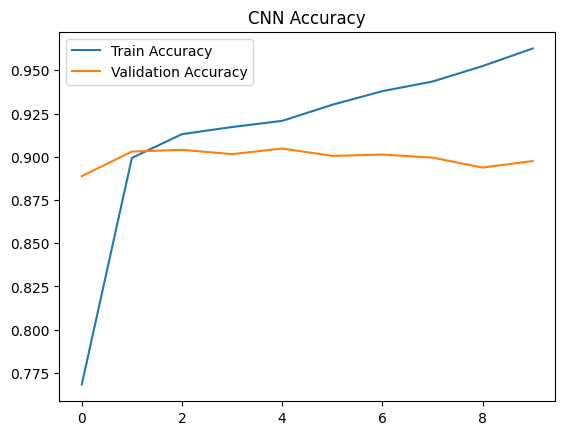

In [40]:
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("CNN Accuracy")
plt.show()

## RL Model

In [41]:
feature_extractor = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3),
    pooling='avg'
)

def extract_features(generator):
    features = []
    labels = []

    for i in range(len(generator)):
        x, y = generator[i]
        f = feature_extractor.predict(x)
        features.append(f)
        labels.append(y)

    return np.vstack(features), np.vstack(labels)

X_train, y_train = extract_features(train_data)
X_val, y_val = extract_features(val_data)

y_train_labels = np.argmax(y_train, axis=1)
y_val_labels = np.argmax(y_val, axis=1)

1/1 [==============================] - 0s 23ms/step


In [42]:
def build_q_network(input_dim, num_actions):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_actions, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

input_dim = X_train.shape[1]
q_model = build_q_network(input_dim, num_classes)

In [49]:
len(X_train)

16000

In [ ]:
epsilon = 1.0
epsilon_decay = 0.95
gamma = 0.9
epochs = 5

rl_accuracy_list = []

for epoch in range(epochs):
    correct = 0

    # for i in range(len(X_train)):
    for i in range(100):
        state = X_train[i]

        # Action selection
        if np.random.rand() < epsilon:
            action = np.random.randint(num_classes)
        else:
            action = np.argmax(q_model.predict(state.reshape(1,-1), verbose=0))

        reward = 1 if action == y_train_labels[i] else -1

        if reward == 1:
            correct += 1

        target = reward

        q_values = q_model.predict(state.reshape(1,-1), verbose=0)
        q_values[0][action] = target

        q_model.fit(state.reshape(1,-1), q_values, verbose=1)

    acc = correct / len(X_train)
    rl_accuracy_list.append(acc)

    epsilon *= epsilon_decay

    print(f"Epoch {epoch+1}, RL Accuracy: {acc:.4f}")

1/1 [==============================] - 0s 8ms/step - loss: 0.0942
Epoch 1, RL Accuracy: 0.0030
1/1 [==============================] - 0s 9ms/step - loss: 0.0850
Epoch 2, RL Accuracy: 0.0033
1/1 [==============================] - 0s 8ms/step - loss: 0.0268
Epoch 3, RL Accuracy: 0.0034
1/1 [==============================] - 0s 7ms/step - loss: 0.0414
Epoch 4, RL Accuracy: 0.0037
1/1 [==============================] - 0s 8ms/step - loss: 0.0618
Epoch 5, RL Accuracy: 0.0031


In [46]:
correct = 0

# for i in range(len(X_val)):
for i in range(100):
    state = X_val[i]
    action = np.argmax(q_model.predict(state.reshape(1,-1), verbose=1))

    if action == y_val_labels[i]:
        correct += 1

rl_val_accuracy = correct / len(X_val)

print("RL Validation Accuracy:", rl_val_accuracy)

1/1 [==============================] - 0s 21ms/step
RL Validation Accuracy: 0.019


In [47]:
cnn_val_acc = max(cnn_history.history['val_accuracy'])

print("CNN Accuracy:", cnn_val_acc)
print("RL Accuracy:", rl_val_accuracy)

CNN Accuracy: 0.9047499895095825
RL Accuracy: 0.019


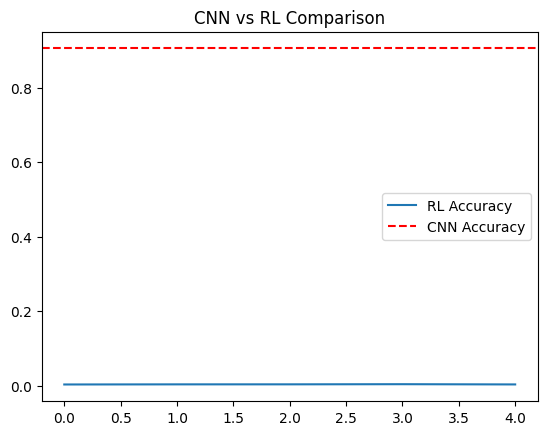

In [48]:
plt.plot(rl_accuracy_list, label='RL Accuracy')
plt.axhline(y=cnn_val_acc, color='r', linestyle='--', label='CNN Accuracy')
plt.legend()
plt.title("CNN vs RL Comparison")
plt.show()